<a href="https://colab.research.google.com/github/nithinpadmanabhuni-eng/Hypothesis-Testing-on-Interest-Rates/blob/main/Mental_Fitness_Tracker.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Mental Fitness Tracker

In [10]:
#importing libraries

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import  Lasso
from sklearn.tree import DecisionTreeRegressor

In [13]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error,r2_score

In [14]:
#reading data csv files

In [15]:
data1 = pd.read_csv('mental-and-substance-use-as-share-of-disease.csv')
data2 = pd.read_csv('prevalence-by-mental-and-substance-use-disorder.csv')

In [16]:
#data information

In [20]:
data1.head()

,Entity,Code,Year,DALYs (Disability-Adjusted Life Years) - Mental disorders - Sex: Both - Age: All Ages (Percent)
0,Afghanistan,AFG,1990,1.696670
1,Afghanistan,AFG,1991,1.734281
2,Afghanistan,AFG,1992,1.791189
3,Afghanistan,AFG,1993,1.776779
4,Afghanistan,AFG,1994,1.712986


In [21]:
data2.head()

,Entity,Code,Year,Prevalence - Schizophrenia - Sex: Both - Age: Age-standardized (Percent),Prevalence - Bipolar disorder - Sex: Both - Age: Age-standardized (Percent),Prevalence - Eating disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Anxiety disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Drug use disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Depressive disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Alcohol use disorders - Sex: Both - Age: Age-standardized (Percent)
0,Afghanistan,AFG,1990,0.228979,0.721207,0.131001,4.835127,0.454202,5.125291,0.444036
1,Afghanistan,AFG,1991,0.228120,0.719952,0.126395,4.821765,0.447112,5.116306,0.444250
2,Afghanistan,AFG,1992,0.227328,0.718418,0.121832,4.801434,0.441190,5.106558,0.445501
3,Afghanistan,AFG,1993,0.226468,0.717452,0.117942,4.789363,0.435581,5.100328,0.445958
4,Afghanistan,AFG,1994,0.225567,0.717012,0.114547,4.784923,0.431822,5.099424,0.445779


In [22]:
#filling mean value to null values

In [23]:
numeric_columns = data1.select_dtypes(include=[np.number]).columns
data1[numeric_columns] = data1[numeric_columns].fillna(data1[numeric_columns].mean())

numeric_columns = data2.select_dtypes(include=[np.number]).columns
data2[numeric_columns] = data2[numeric_columns].fillna(data2[numeric_columns].mean())

In [24]:
data1.head()

,Entity,Code,Year,DALYs (Disability-Adjusted Life Years) - Mental disorders - Sex: Both - Age: All Ages (Percent)
0,Afghanistan,AFG,1990,1.696670
1,Afghanistan,AFG,1991,1.734281
2,Afghanistan,AFG,1992,1.791189
3,Afghanistan,AFG,1993,1.776779
4,Afghanistan,AFG,1994,1.712986


In [25]:
data1.tail()

,Entity,Code,Year,DALYs (Disability-Adjusted Life Years) - Mental disorders - Sex: Both - Age: All Ages (Percent)
6835,Zimbabwe,ZWE,2015,2.193166
6836,Zimbabwe,ZWE,2016,2.279813
6837,Zimbabwe,ZWE,2017,2.364265
6838,Zimbabwe,ZWE,2018,2.472949
6839,Zimbabwe,ZWE,2019,2.525892


In [26]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6840 entries, 0 to 6839
Data columns (total 4 columns):
 #   Column                                                                                           Non-Null Count  Dtype  
---  ------                                                                                           --------------  -----  
 0   Entity                                                                                           6840 non-null   object 
 1   Code                                                                                             6150 non-null   object 
 2   Year                                                                                             6840 non-null   int64  
 3   DALYs (Disability-Adjusted Life Years) - Mental disorders - Sex: Both - Age: All Ages (Percent)  6840 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 213.9+ KB


In [27]:
data1.describe()

,Year,DALYs (Disability-Adjusted Life Years) - Mental disorders - Sex: Both - Age: All Ages (Percent)
count,6840.000000,6840.000000
mean,2004.500000,4.818062
std,8.656074,2.294029
min,1990.000000,0.215647
25%,1997.000000,3.006507
50%,2004.500000,4.679177
75%,2012.000000,6.387488
max,2019.000000,13.761517


In [28]:
data2.head()

,Entity,Code,Year,Prevalence - Schizophrenia - Sex: Both - Age: Age-standardized (Percent),Prevalence - Bipolar disorder - Sex: Both - Age: Age-standardized (Percent),Prevalence - Eating disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Anxiety disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Drug use disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Depressive disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Alcohol use disorders - Sex: Both - Age: Age-standardized (Percent)
0,Afghanistan,AFG,1990,0.228979,0.721207,0.131001,4.835127,0.454202,5.125291,0.444036
1,Afghanistan,AFG,1991,0.228120,0.719952,0.126395,4.821765,0.447112,5.116306,0.444250
2,Afghanistan,AFG,1992,0.227328,0.718418,0.121832,4.801434,0.441190,5.106558,0.445501
3,Afghanistan,AFG,1993,0.226468,0.717452,0.117942,4.789363,0.435581,5.100328,0.445958
4,Afghanistan,AFG,1994,0.225567,0.717012,0.114547,4.784923,0.431822,5.099424,0.445779


In [29]:
data2.tail()

,Entity,Code,Year,Prevalence - Schizophrenia - Sex: Both - Age: Age-standardized (Percent),Prevalence - Bipolar disorder - Sex: Both - Age: Age-standardized (Percent),Prevalence - Eating disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Anxiety disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Drug use disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Depressive disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Alcohol use disorders - Sex: Both - Age: Age-standardized (Percent)
6835,Zimbabwe,ZWE,2015,0.209359,0.560882,0.099610,3.315701,0.599604,3.548613,1.734969
6836,Zimbabwe,ZWE,2016,0.209979,0.561768,0.100821,3.324230,0.603658,3.557508,1.689281
6837,Zimbabwe,ZWE,2017,0.210631,0.562612,0.101671,3.330569,0.608096,3.564138,1.651805
6838,Zimbabwe,ZWE,2018,0.211237,0.563283,0.102398,3.317500,0.609065,3.563141,1.686711
6839,Zimbabwe,ZWE,2019,0.211969,0.563820,0.102902,3.283934,0.610644,3.554571,1.776729


In [30]:
data2.describe()

,Year,Prevalence - Schizophrenia - Sex: Both - Age: Age-standardized (Percent),Prevalence - Bipolar disorder - Sex: Both - Age: Age-standardized (Percent),Prevalence - Eating disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Anxiety disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Drug use disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Depressive disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Alcohol use disorders - Sex: Both - Age: Age-standardized (Percent)
count,6840.000000,6840.000000,6840.000000,6840.000000,6840.000000,6840.000000,6840.000000,6840.000000
mean,2004.500000,0.281167,0.673891,0.211062,4.327525,0.746708,3.950449,1.578807
std,8.656074,0.047561,0.258594,0.152559,1.177961,0.463026,0.921021,0.934655
min,1990.000000,0.191621,0.189344,0.045425,1.974823,0.225471,1.640902,0.319900
25%,1997.000000,0.255468,0.539791,0.099857,3.567064,0.423502,3.258977,0.732826
50%,2004.500000,0.287456,0.591893,0.154143,4.094443,0.646050,3.904117,1.460045
75%,2012.000000,0.304760,0.897248,0.276891,4.797286,0.890013,4.550505,2.261262
max,2019.000000,0.506018,1.676204,1.136541,9.015948,3.699504,7.688213,4.698694


In [31]:
data1.shape

(6840, 4)

In [32]:
data2.shape

(6840, 10)

In [33]:
#merged_df = pd.merge(data1, data2, on=['Entity', 'Code', 'Year'])
merged_df= pd.merge(data2,data1)
merged_df.head()

,Entity,Code,Year,Prevalence - Schizophrenia - Sex: Both - Age: Age-standardized (Percent),Prevalence - Bipolar disorder - Sex: Both - Age: Age-standardized (Percent),Prevalence - Eating disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Anxiety disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Drug use disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Depressive disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Alcohol use disorders - Sex: Both - Age: Age-standardized (Percent),DALYs (Disability-Adjusted Life Years) - Mental disorders - Sex: Both - Age: All Ages (Percent)
0,Afghanistan,AFG,1990,0.228979,0.721207,0.131001,4.835127,0.454202,5.125291,0.444036,1.696670
1,Afghanistan,AFG,1991,0.228120,0.719952,0.126395,4.821765,0.447112,5.116306,0.444250,1.734281
2,Afghanistan,AFG,1992,0.227328,0.718418,0.121832,4.801434,0.441190,5.106558,0.445501,1.791189
3,Afghanistan,AFG,1993,0.226468,0.717452,0.117942,4.789363,0.435581,5.100328,0.445958,1.776779
4,Afghanistan,AFG,1994,0.225567,0.717012,0.114547,4.784923,0.431822,5.099424,0.445779,1.712986


In [34]:
#data1.isnull().sum()
#data2.isnull().sum()
merged_df.isnull().sum()

,0
Entity,0
Code,690
Year,0
Prevalence - Schizophrenia - Sex: Both - Age: Age-standardized (Percent),0
Prevalence - Bipolar disorder - Sex: Both - Age: Age-standardized (Percent),0
Prevalence - Eating disorders - Sex: Both - Age: Age-standardized (Percent),0
Prevalence - Anxiety disorders - Sex: Both - Age: Age-standardized (Percent),0
Prevalence - Drug use disorders - Sex: Both - Age: Age-standardized (Percent),0
Prevalence - Depressive disorders - Sex: Both - Age: Age-standardized (Percent),0
Prevalence - Alcohol use disorders - Sex: Both - Age: Age-standardized (Percent),0


In [35]:
merged_df.drop('Code', axis=1, inplace=True)

In [43]:
merged_df = merged_df.set_axis(
[
'Country',
'Year',
'Schizophrenia',
'Bipolar_disorder',
'Eating_disorder',
'Anxiety',
'drug_usage',
'depression',
'alcohol',
'mental_fitness'
],
axis='columns'
)

In [37]:
merged_df.head()

,Entity,Year,Prevalence - Schizophrenia - Sex: Both - Age: Age-standardized (Percent),Prevalence - Bipolar disorder - Sex: Both - Age: Age-standardized (Percent),Prevalence - Eating disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Anxiety disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Drug use disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Depressive disorders - Sex: Both - Age: Age-standardized (Percent),Prevalence - Alcohol use disorders - Sex: Both - Age: Age-standardized (Percent),DALYs (Disability-Adjusted Life Years) - Mental disorders - Sex: Both - Age: All Ages (Percent)
0,Afghanistan,1990,0.228979,0.721207,0.131001,4.835127,0.454202,5.125291,0.444036,1.696670
1,Afghanistan,1991,0.228120,0.719952,0.126395,4.821765,0.447112,5.116306,0.444250,1.734281
2,Afghanistan,1992,0.227328,0.718418,0.121832,4.801434,0.441190,5.106558,0.445501,1.791189
3,Afghanistan,1993,0.226468,0.717452,0.117942,4.789363,0.435581,5.100328,0.445958,1.776779
4,Afghanistan,1994,0.225567,0.717012,0.114547,4.784923,0.431822,5.099424,0.445779,1.712986


###Exploring Data Analysis

In [38]:
#heatmap

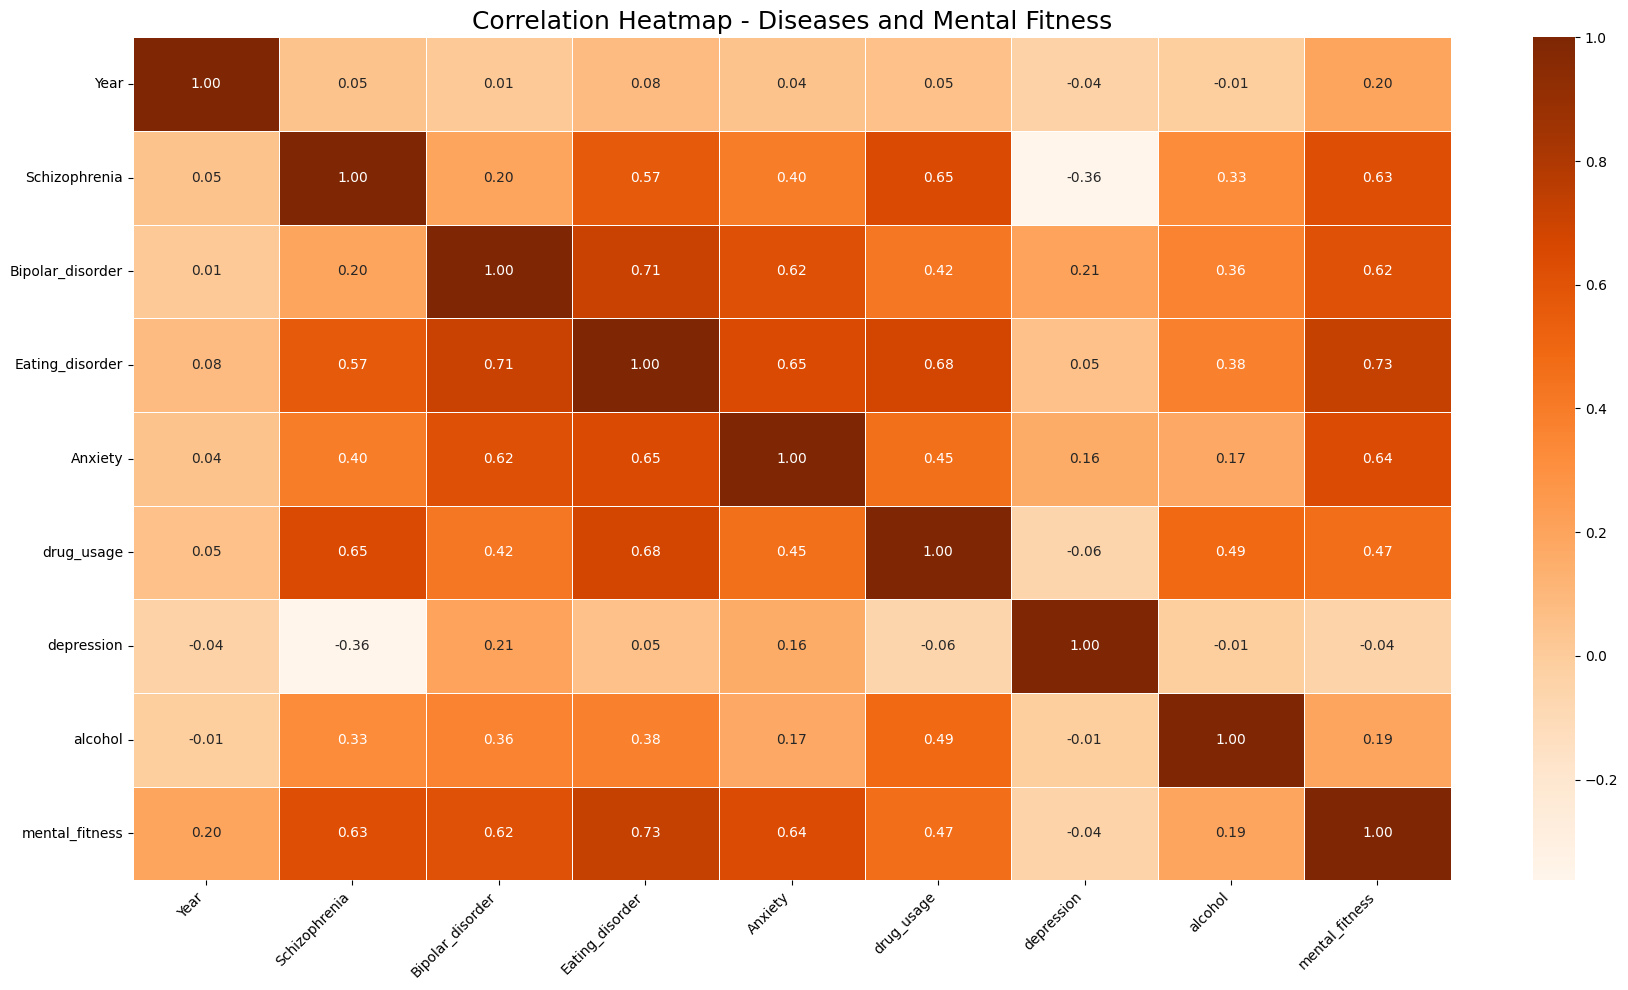

In [45]:
numeric_df = merged_df.select_dtypes(include=['number'])

# Create heatmap
plt.figure(figsize=(18,10))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='Oranges',
    linewidths=0.5,
    fmt='.2f'
)

plt.title(
    'Correlation Heatmap - Diseases and Mental Fitness',
    fontsize=18
)

plt.xticks(
    rotation=45,
    ha='right',
    fontsize=10
)

plt.yticks(
    rotation=0,
    fontsize=10
)

plt.tight_layout()

plt.show()

In [46]:
#pairplot

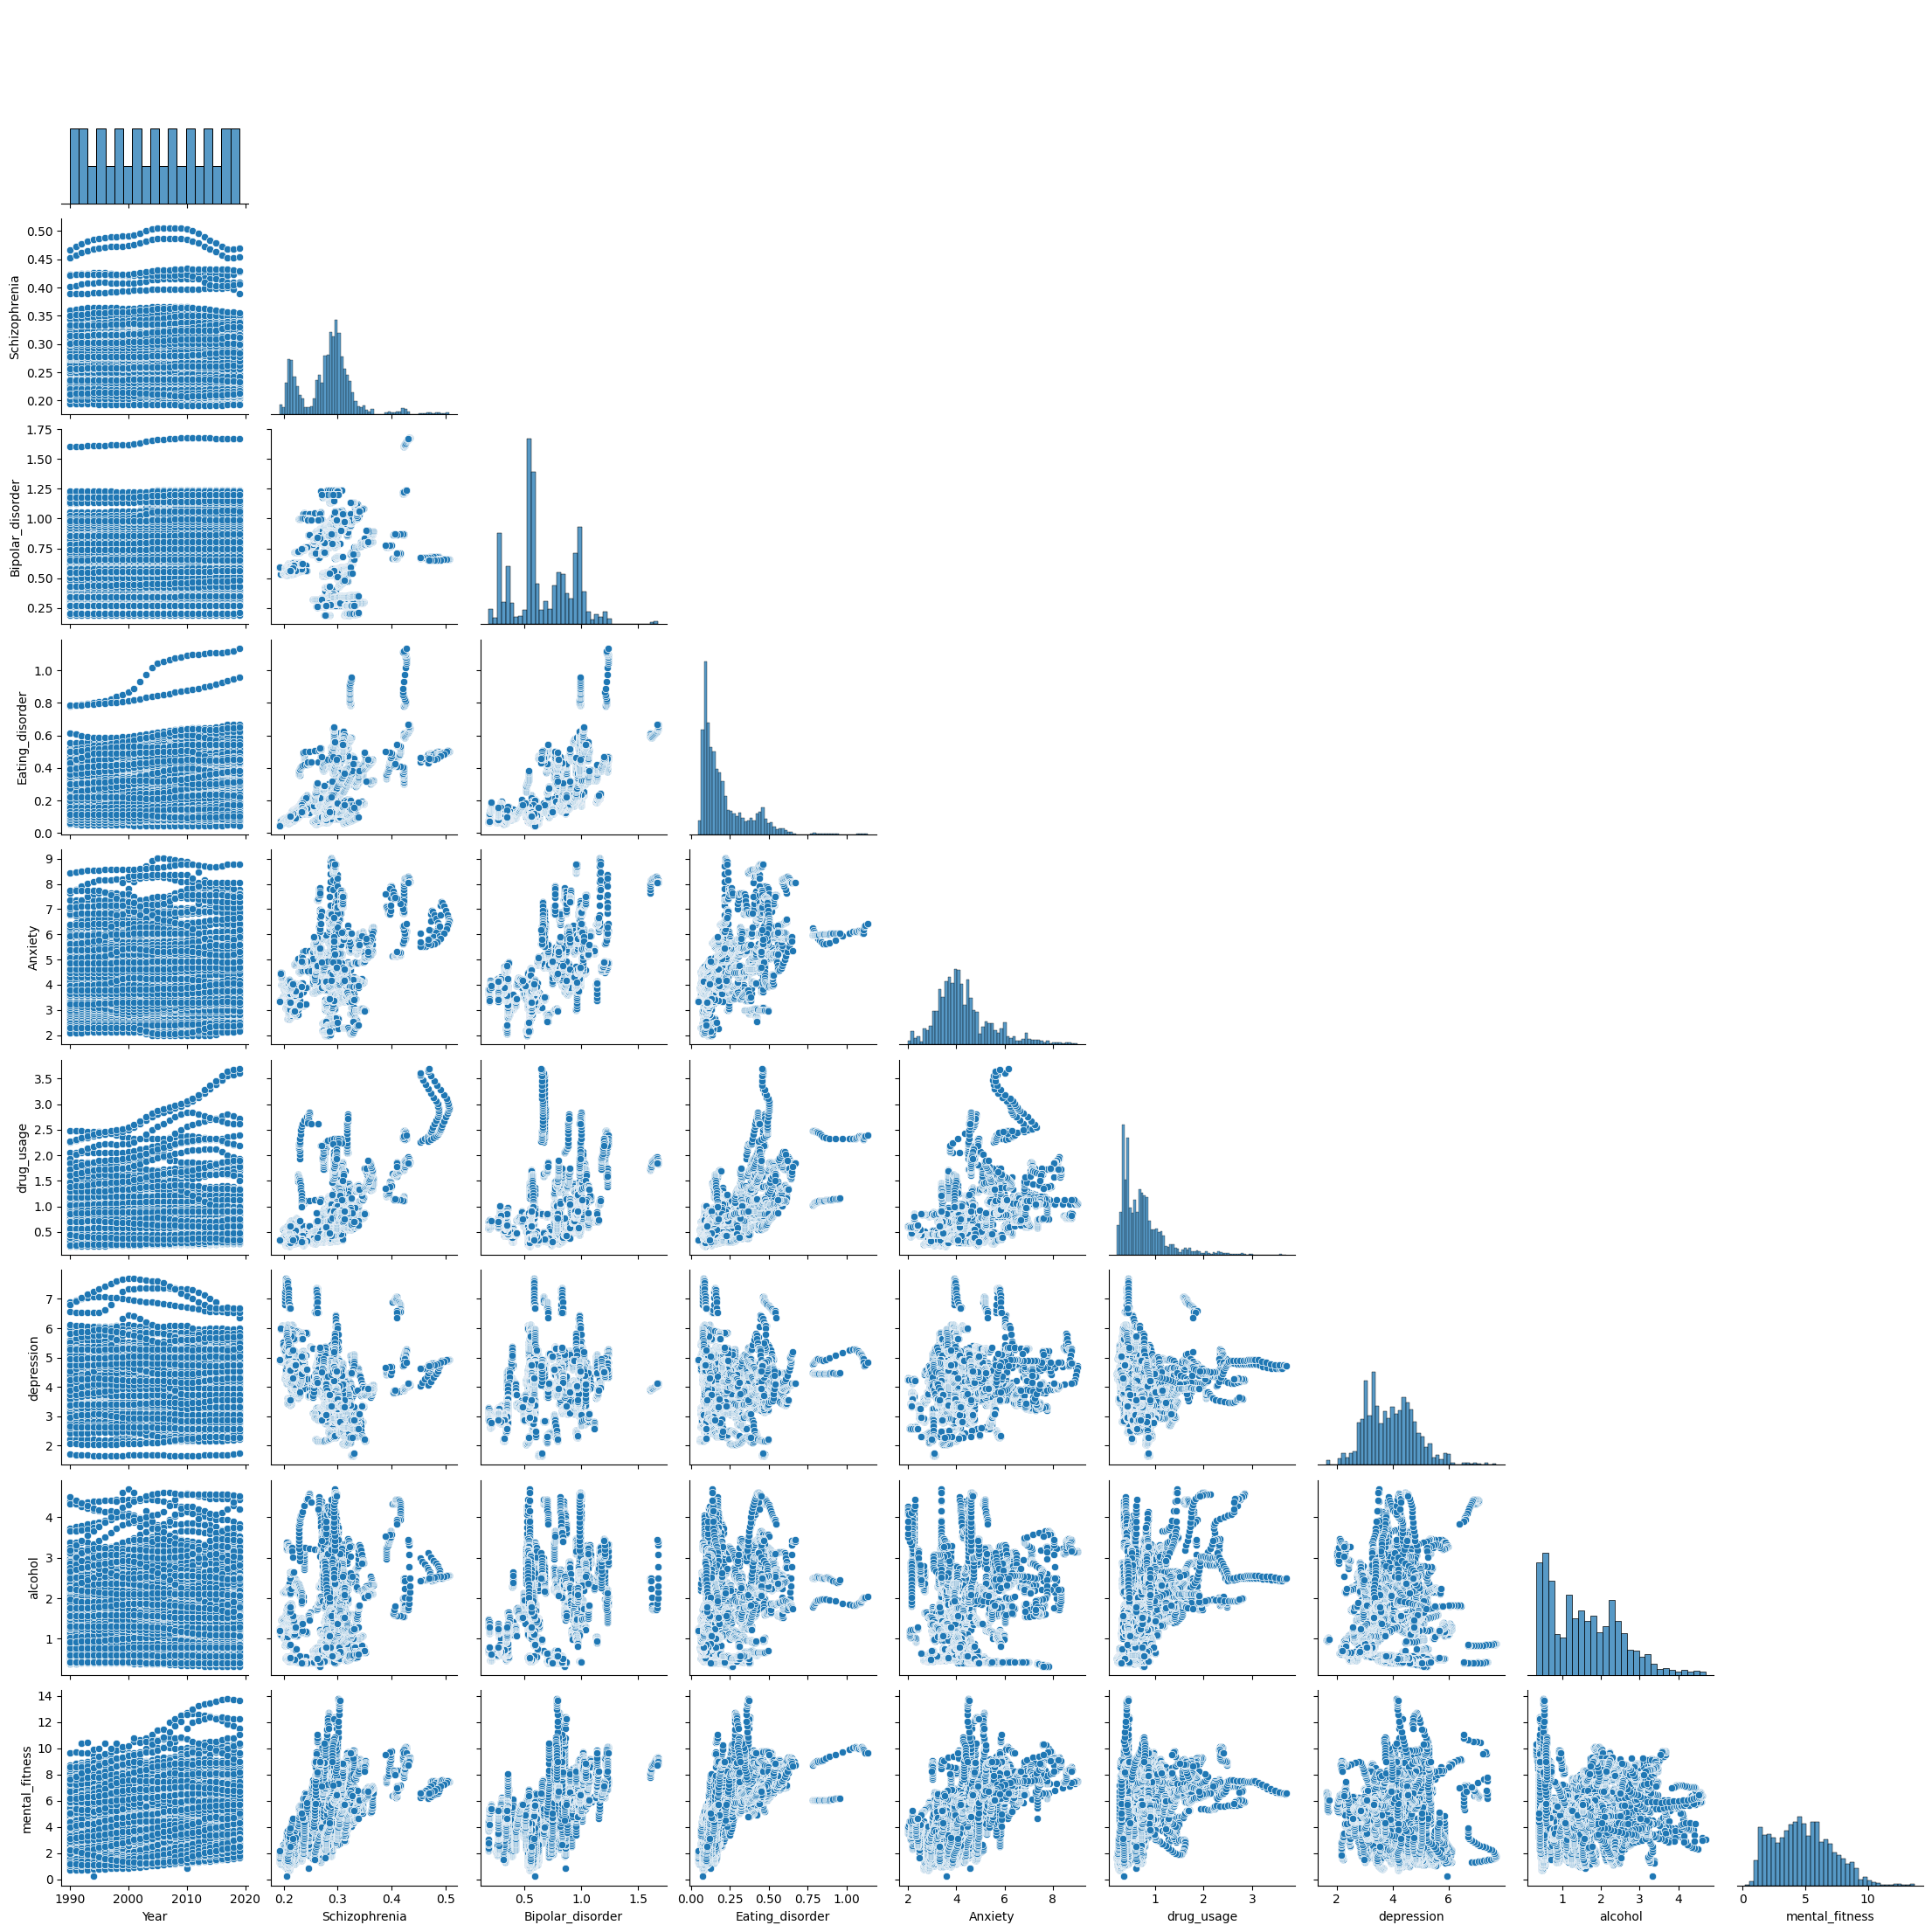

In [47]:
sns.pairplot(merged_df,corner=True)
plt.show()

In [54]:
df = merged_df
df.shape

(6840, 10)

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6840 entries, 0 to 6839
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Country           6840 non-null   object 
 1   Year              6840 non-null   int64  
 2   Schizophrenia     6840 non-null   float64
 3   Bipolar_disorder  6840 non-null   float64
 4   Eating_disorder   6840 non-null   float64
 5   Anxiety           6840 non-null   float64
 6   drug_usage        6840 non-null   float64
 7   depression        6840 non-null   float64
 8   alcohol           6840 non-null   float64
 9   mental_fitness    6840 non-null   float64
dtypes: float64(8), int64(1), object(1)
memory usage: 534.5+ KB


In [56]:
from sklearn.preprocessing import LabelEncoder
l = LabelEncoder()
for i in merged_df.columns:
    if merged_df[i].dtype == 'object':
        merged_df[i]=l.fit_transform(merged_df[i])

In [57]:
#data read into X and y

In [58]:
X = df.drop('mental_fitness',axis=1)
y = df['mental_fitness']

In [59]:
#traing and testing data set

In [60]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=2)

In [61]:
print('shapes of training and testing datasets\n')
print('X_train : ',X_train.shape)
print('y_train : ',y_train.shape)
print('X_test : ',X_test.shape)
print('y_train : ',y_test.shape)

shapes of training and testing datasets

X_train :  (4788, 9)
y_train :  (4788,)
X_test :  (2052, 9)
y_train :  (2052,)


#Linear Regression

In [62]:
lr = LinearRegression()
lr.fit(X_train,y_train)

y_predict = lr.predict(X_train) #Predicting the y based on training
mse = mean_squared_error(y_train,y_predict) #difference blw observed value and predicted value
rmse = np.sqrt(mse) #differenct blw predicted and actual values
r2 = r2_score(y_train,y_predict)

print("Linear Regression Model Performance : (Training) \n")
print("MSE : {}".format(mse))
print("RMSE : {}".format(rmse))
print("r2 : {}".format(r2))

Linear Regression Model Performance : (Training) 

MSE : 1.404245110290924
RMSE : 1.1850084853244403
r2 : 0.7388102864134181


In [63]:
y_predict = lr.predict(X_test) #Predicting the y based on training
mse = mean_squared_error(y_test,y_predict) #difference blw observed value and predicted value
rmse = np.sqrt(mse) #differenct blw predicted and actual values
r2 = r2_score(y_test,y_predict)

print("Linear Regression Model Performance : (Testing) \n")
print("MSE : {}".format(mse))
print("RMSE : {}".format(rmse))
print("r2 : {}".format(r2))


Linear Regression Model Performance : (Testing) 

MSE : 1.1903814576372342
RMSE : 1.0910460382757614
r2 : 0.7608823856584933


##Lasso

In [65]:
ls = Lasso(alpha=0.5)
ls.fit(X_train, y_train)
y_predict2 = ls.predict(X_train) #Predicting the y based on training

mse = mean_squared_error(y_train,y_predict2) #difference blw observed value and predicted value
rmse = np.sqrt(mse) #differenct blw predicted and actual values
r2 = r2_score(y_train,y_predict2)

print("  Lasso Regression Model Performance : \n")
print("MSE : {}".format(mse))
print("RMSE : {}".format(rmse))
print("r2 : {}".format(r2))

  Lasso Regression Model Performance : 

MSE : 3.22272117568985
RMSE : 1.7951939103310957
r2 : 0.40057357887224054


#RandomForest Regression

In [66]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()
rf.fit(X_train,y_train)

y_predict = rf.predict(X_train)#Predicting the y based on training
mse = mean_squared_error(y_train,y_predict) #difference blw observed value and predicted value
rmse = np.sqrt(mse) #differenct blw predicted and actual values
r2 = r2_score(y_train,y_predict)
print(" Random Forest Regression Model Performance : (Training) \n")
print("MSE : {}".format(mse))
print("RMSE : {}".format(rmse))
print("r2 : {}".format(r2))

 Random Forest Regression Model Performance : (Training) 

MSE : 0.005880637059983949
RMSE : 0.07668531189206933
r2 : 0.9989062009914454


In [67]:
ytest_predict = rf.predict(X_test)#Predicting the y based on training
mse = mean_squared_error(y_test,ytest_predict) #difference blw observed value and predicted value
rmse = np.sqrt(mse) #differenct blw predicted and actual values
r2 = r2_score(y_test,ytest_predict)
print(" Random Forest Regression Model Performance : (Testing)\n")
print("MSE : {}".format(mse))
print("RMSE : {}".format(rmse))
print("r2 : {}".format(r2))

 Random Forest Regression Model Performance : (Testing)

MSE : 0.03463715715031029
RMSE : 0.18611060461540144
r2 : 0.9930422686507622


#Conclusion

The most precise model is: Random Forest Regression

The least precise model is: Lasso Regression